# Using Fourier Transforms to Classify Music Genres

Math 104, Winter 2025.

The GTZAN audio (~1.2 GB) is not included in this repository, so the cells below will
not run as-is. **The saved outputs are from the original run.** To re-execute, download
the dataset from Kaggle and extract it to `data/genres_original/` — see the README.

In [ ]:
# Run this once to install required libraries
!pip install numpy matplotlib librosa scikit-learn pandas imbalanced-learn xgboost

In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

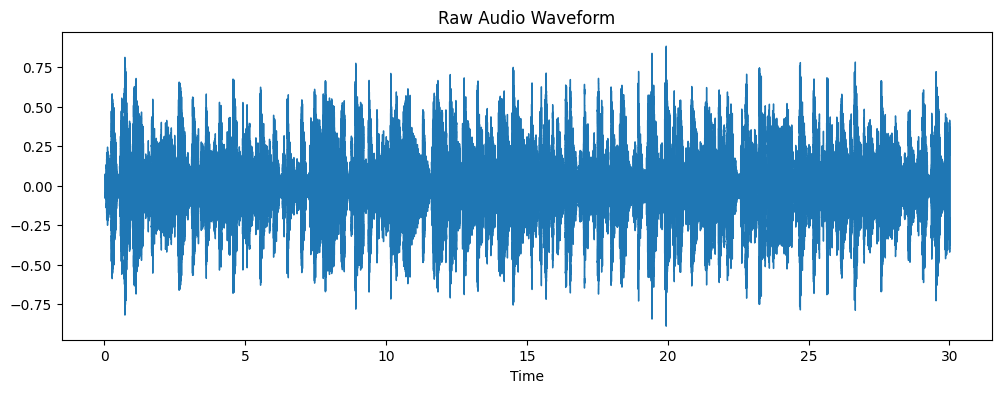

In [3]:
# Load an example audio file
file_path = "data/genres_original/blues/blues.00000.wav"
audio, sr = librosa.load(file_path, sr=22050, mono=True)  # 22.05 kHz

# Plot the raw waveform
os.makedirs("figures", exist_ok=True)
plt.figure(figsize=(12, 4))
librosa.display.waveshow(audio, sr=sr)
plt.title("Raw Audio Waveform")
plt.savefig("figures/waveform_blues00000.png", dpi=150, bbox_inches="tight")
plt.show()

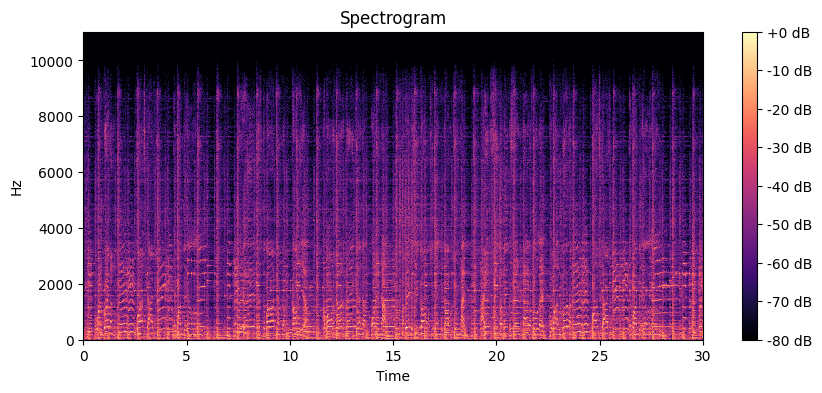

In [4]:
# Compute STFT and plot spectrogram
D = librosa.stft(audio)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.savefig("figures/spectrogram_blues00000.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
def extract_features(audio, sr):
    # Existing features
    stft = librosa.stft(audio)
    spectrogram = librosa.amplitude_to_db(np.abs(stft), ref=np.max)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
    zero_crossing_rate = librosa.feature.zero_crossing_rate(audio)
    
    # New features
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)
    chroma_stft = librosa.feature.chroma_stft(y=audio, sr=sr)
    tempo, _ = librosa.beat.beat_track(y=audio, sr=sr)  # Tempo extraction
    tempo = float(np.atleast_1d(tempo)[0])  # librosa >=0.10 returns an array

    # Aggregate features
    features = np.concatenate([
        np.mean(spectrogram, axis=1),
        np.mean(mfcc, axis=1),
        [np.mean(spectral_centroid)],
        [np.mean(zero_crossing_rate)],
        [np.mean(spectral_bandwidth)], 
        [np.mean(spectral_rolloff)],
        np.mean(chroma_stft, axis=1),
        [tempo]  # Tempo is a scalar, wrap in []
    ])
    return features

In [ ]:
dataset_path = "data/genres_original"
genres = sorted(d for d in os.listdir(dataset_path)
                if os.path.isdir(os.path.join(dataset_path, d)))

data = []

for genre in genres:
    genre_path = os.path.join(dataset_path, genre)
    for file in os.listdir(genre_path):
        file_path = os.path.join(genre_path, file)
        try:
            audio, sr = librosa.load(file_path, sr=22050, mono=True, res_type='kaiser_fast')
            features = extract_features(audio, sr)  # Make sure `extract_features` is defined!
            data.append({'genre': genre, 'features': features})
        except Exception as e:
            print(f"Skipping file {file_path}: {e}")
            continue

df = pd.DataFrame(data)
df.to_csv('features.csv', index=False)

In [7]:
# Split data into features (X) and labels (y)
X = np.array(df['features'].tolist())
y = df['genre']

# Encode labels to integers
le = LabelEncoder()
y = le.fit_transform(y)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Apply SMOTE to address class imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Apply PCA to the resampled data
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_res)
X_test_pca = pca.transform(X_test)  # Transform test data using the same PCA

# Hyperparameter tuning for XGBoost
model = XGBClassifier(objective='multi:softprob', random_state=42)
param_grid = {
    'n_estimators': [100, 200],    # Number of trees
    'max_depth': [3, 5, 7],        # Depth of trees
    'learning_rate': [0.01, 0.1],  # Step size
    'subsample': [0.8, 1.0]        # Fraction of samples per tree
}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_pca, y_train_res)  # Use PCA-transformed resampled data

# Evaluate
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_pca)  # Predict on PCA-transformed test data
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

# Optional: Map predictions back to genre names
y_pred_labels = le.inverse_transform(y_pred)

Accuracy: 0.64
